<center><h1> ETI195 - Ética para Ciencia de Datos y Estadística </h1><center>
<center><h2> Taller Sumativo II: Sesgos, justicia, y discriminación <h2></center>

# `Instrucciones Generales`


## `Temas formales`

**Modalidad**: Grupos de 3 o 4 personas.

**Formato de entrega:** El trabajo debe entregarse a través de Canvas, tanto en formato Jupyter ejecutable (.ipynb) como en formato PDF.

**Formalidades de las respuestas:**
- Citas: APA 7.
- Se espera buena ortografía y redacción, con respuestas en tono académico.

## `Recomendaciones`

- Asistan a los talleres formativos, revisen los ejemplos de código y consulten sus dudas con sus ayudantes.

- **Lean la rúbrica antes de hacer su tarea.**

## `Integridad académica y uso de IA`

El uso de asistentes de IA sigue los lineamientos de integridad académica del curso, con las siguientes excepciones:

- Pueden usar IA para consultar por bugs y entender mejor el código.
- Pueden usar IA para generar las representaciones visuales que estimen convenientes.

Si tienen dudas sobre el uso de IA o la citación de código externo, no duden en preguntar. Pueden usar libremente los códigos de los talleres formativos. <3

## `Contexto`

Reducir el respeto de un gobierno por los derechos humanos a un puntaje o una etiqueta binaria no es una decisión libre de impacto,  estos números son usados por organismos internacionales, ONGs y gobiernos para decidir ayuda económica, sanciones o intervención humanitaria. Un modelo entrenado sobre estos datos hereda las limitaciones de cómo se construyó el puntaje original ya sea en los criterios de codificación, por  sesgo de las fuentes usadas para calificar cada país mediante informes de prensa, ONGs, gobierno y la dificultad de capturar violaciones que ocurren en contextos con poca cobertura mediática, por lo que puede terminar prediciendo mejor la visibilidad de una violación que la violación misma.

En este taller entrenarán un modelo predictivo sobre alguna variable binaria de interés del dataset (algún derecho), por ejemplo Women's Political Rights, evaluando qué tan bien un modelo puede clasificar el respeto a ese derecho a partir de las demás variables disponibles, y discutiendo qué implicaría usar ese tipo de modelo para influir en decisiones reales sobre un país.

**Links:**
- [Datos](https://drive.google.com/file/d/1mL1oL_D1af42Uxgif-QonneldffPhGhu/view?usp=drive_link)
- [Diccionario de datos resumen](https://drive.google.com/file/d/17Fm64SksQofOmI4iNuReCsJk2o-Qghq8/view?usp=sharing)
- [Diccionario de extendido](https://drive.google.com/file/d/1cAvH2oLWW5whMiaoSEPwDmFaTqOEPqvl/view?usp=sharing)

**Integrantes:**

- Antonella Ainzúa
- Vicente de Gavardo
- Camila Matamala
- Octavia Robledo

---

## Parte 1

Lean nuevamente los materiales de contexto del dataset que pueden encontrar en la [página oficial](http://www.humanrightsdata.com/p/data-documentation.html). Deben comprender qué información captura el dataset y qué impacto podría tener entrenar modelos de clasificación en contextos de violaciones a los derechos humanos.

### **RESPONDER**

1.  Discuta los objetivos del datset CIRI con referencias a la metodología y para qué serviría entrenar un clasificador automático para predecir cumplimiento de derechos humanos, recuerden que siempre pueden apoyarse en bibliografía.

#### **R1**
* **Objetivos data set** CIRI Human RIghts Data Project mide el respeto de los gobiernos hacia 15 derechos humanos reconocidos internacionalmente en 202 países, de forma anual entre 1981 y 2011. 
<br>
Su propósito es ofrecer medidas estandarizadas y comparables de forma que académicos y analistas puedan poner a prueba teorías sobre las causas y consecuencias de las violaciones de los derechos humanos y evaluar políticas como la ayuda económica, militar, la democratización o intervención humanitaria.

* **Metodología** Ciri no mide hechos en concreto, más bien codifica informes. Personas entrenadas leen los *Country Reports on Human Right Practices* del Departamento de Estado de EE.UU y para los derechos de integridad física, los informes de Amnistía Internacional. A cada país-año le asignan un puntaje ordinal según un manual de codificación. Por ejemplo, 0 = restricción severa, 1 = restricción moderada y 2 = respeto pleno (Cingranelli & Richards, 2010).
<br>
Como vimos en el taller 1, esto implica que cada número es un juicio humano estandarizado sobre un texto, no una observación directa de la realidad.

**Tener en cuenta a la hora de entrenar un modelo**
*  *Sesgo de la fuente*: Los informes del Departamento de Estado han tendido a ser más benévolos con países aliados de EE.UU. que los de Amnistía Internacional (https://muse.jhu.edu/article/13792) (Poe et al., 2001)
* *Efectos de información*: a medida que aumenta la cobertura de ONG y medios, se reportan más violaciones sin que necesariamente haya más según Clark & Sikkink, 2013
* *Estándar de rendición de cuentas cambiante:* los informes se vuelven más exigentes con el tiempo, asi que un mismo puntaje no significa lo mismo en 1981 que en 2009

**Utilidad de un clasificador automático**
Podría servir para estimar el respeto a un derecho en país-años sin codificar: 

CIRI termina en 2011 y tiene vacíos por códigos especiales. 

También podría funcionar como alerta temprana o como apoyo para priorizar el monitoreo de organismos internacionales y ONG. El riesgo es que estos puntajes ya se usan para decidir ayuda, sanciones o intervenciones.Un modelo entrenado con ellos hereda los sesgos de la fuente y **puede terminar prediciendo mejor la *visibilidad* de una violación que la violación misma** tal como advierte el enunciado. Por eso, más que *cuánto acierta* lo importante es *para quién se equivoca*.

## Librerias y configuraciones

In [13]:
# imports iniciales
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import sklearn as skl

In [14]:
# %pip install aequitas

In [15]:
# aequitas
from aequitas.group import Group

In [16]:
# %pip install aif360

In [17]:
# aif360
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric
from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.postprocessing.eq_odds_postprocessing import EqOddsPostprocessing
from aif360.algorithms.preprocessing import Reweighing
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset


import warnings
warnings.filterwarnings("ignore")

## Parte 2: Realice el preprocesamiento de los datos y entrene un árbol de decisión para predecir algún derecho humano de interés.

*Puede reutilizar el jupyter o trabajar con el mismo jupyter de la entrega anterior, puede entregar una carpeta con ambos jupyter y funciones compartidas*

Reporte el accuracy y la matriz de confusión sobre los datos de testeo.

### Resumen de lo realizado en la entrega anterior:

In [18]:
# LECTURA DE DATOS
df = pd.read_csv('Data/ciri_data.csv')

# CORRECCIÓN TIPO DE DATOS
df["UN Country ID"] = df["UN Country ID"].astype("Int64")

# Eliminación datos menores a 0
df_clean = df.copy()
columnas_derechos = df_clean.columns[6:]

codigos_especiales = [-999, -77, -66]

for columna in columnas_derechos:
  df_clean[columna] = df_clean[columna].replace(codigos_especiales, np.nan)

# Estandarizamos todos los tipos de nulos a 'np.nan' por conversión de tipo
for columna in columnas_derechos:
    df_clean[columna] = pd.to_numeric(df_clean[columna], errors="coerce").astype(float)

# SELECCIÓN DE COLUMNAS (DERECHOS) DE INTERÉS
df_test = df_clean.copy()
# Convertir a tipo categoría Region y Subregion
df_test['UN Subregion'] = df_test['UN Subregion'].astype("category")
df_test['UN Region'] = df_test['UN Region'].astype("category")

# Filtramos por año >= 2000 en que Freedom of Religion es == 2
df_filtrado = df_test[(df_test["Year"] >= 2000) & (df_test["Freedom of Religion (New)"] == 2)]
# Se hace un conteo de los casos y se agrupna por Year y Sub region
conteo_por_año = (df_filtrado.groupby(["Year", "UN Subregion"], observed=True).size().reset_index(name="Cantidad_Casos"))

# print("\t SUBREGIONES CON FREEDOM OF RELIGION (NEW) == 2 POR AÑO (DESDE EL 2000)\n")
# print(conteo_por_año.to_string(index=False))# No muestra el indice

In [19]:
# DISTRIBUCIÓN DE LOS ATRIBUTOS ELEGIDOS DENTRO DE LA SUBPOBLACIÓN
# Relación entre Freedom of Religion (New) y Women's Social Rights
# Se descartan NaN en ambas columnas para esta comparación puntual
df_relacion = df_clean[["Freedom of Religion (New)", "Women’s Social Rights"]].dropna()
df_relacion = df_relacion.astype(int)

# Tabla de conteo (cuántos país-año caen en cada combinación)
tabla_conteo = pd.crosstab(
    df_relacion["Freedom of Religion (New)"],
    df_relacion["Women’s Social Rights"],
)
print("\t CONTEO: FREEDOM OF RELIGION (NEW) x WOMEN'S SOCIAL RIGHTS\n")
print(tabla_conteo.to_string())

# Tabla porcentual: dentro de cada nivel de libertad religiosa,
# cómo se distribuyen los derechos sociales de las mujeres
tabla_pct = pd.crosstab(
    df_relacion["Freedom of Religion (New)"],
    df_relacion["Women’s Social Rights"],
    normalize="index",
) * 100
print("\n\t % POR FILA (dentro de cada nivel de Freedom of Religion)\n")
print(tabla_pct.round(1).to_string())

	 CONTEO: FREEDOM OF RELIGION (NEW) x WOMEN'S SOCIAL RIGHTS

Women’s Social Rights        0    1    2    3
Freedom of Religion (New)                    
0                          246  431  127    6
1                          200  495  177   50
2                          184  918  521  293

	 % POR FILA (dentro de cada nivel de Freedom of Religion)

Women’s Social Rights         0     1     2     3
Freedom of Religion (New)                        
0                          30.4  53.2  15.7   0.7
1                          21.7  53.7  19.2   5.4
2                           9.6  47.9  27.2  15.3


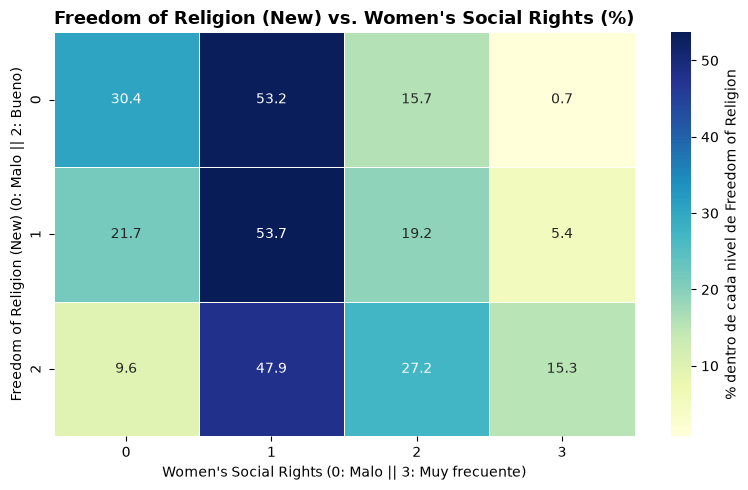

In [20]:
# Heatmap para visualizar la relación
plt.figure(figsize=(8, 5))

sns.heatmap(
    tabla_pct,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={"label": "% dentro de cada nivel de Freedom of Religion"},
    linewidths=0.5,
    linecolor="white",
)

plt.title("Freedom of Religion (New) vs. Women's Social Rights (%)", fontsize=13, fontweight="bold")
plt.xlabel("Women's Social Rights (0: Malo || 3: Muy frecuente)")
plt.ylabel("Freedom of Religion (New) (0: Malo || 2: Bueno)")
plt.tight_layout()
plt.show()

### Indicaciones

**1 Elección del tipo de clasificador**

Dependiendo del atributo que escoja, podría tener que entrenar un clasificador binario o un clasificador multiclase:

- Un clasificador binario se utiliza cuando la variable objetivo es binaria, como en el caso de Freedom of Religion, que tiene como opciones 0 o 1.
- Un clasificador multiclase se utiliza cuando la variable objetivo tiene más de dos categorías, como en el caso de Worker's Rights, que tiene las opciones 0, 1 y 2.
- Para casos de mayor dimensión, recomiendo evaluar la manera de binarizar o disminuir la dimensión; recuerden que estas decisiones siempre deben estar justificadas.

**2 Manejo de códigos especiales**

La `**variable objetivo**` debe restringirse a los valores que efectivamente miden el derecho humano en cuestión, excluyendo los siguientes 3 casos especiales que contempla el libro de código [-999, -77, -66]. Si el caso cae en alguno de estos 3 códigos, se debe tomar una decisión de limpieza sobre esos datos mediante la técnica de manejo de valores faltantes que estimen conveniente. Esta decisión no es trivial y puede afectar mucho el modelo, deben reflexionar al respecto.

**3 Otras indicaciones del preprocesamiento**

- El preprocesamiento debe incluir al menos: manejo de valores faltantes, codificación de variables categóricas, normalización de variables numéricas y tratamiento de valores extremos.

- Utilice random_state o semillas donde corresponda para garantizar la reproducibilidad de los resultados.

- La variable objetivo podría estaár desbalanceada. Investigue el argumento class_weight='balanced' de sklearn para manejar este problema y aplíquelo si lo considera pertinente.

### **RESPONDER**

2.1 Explique y justifique los pasos del preprocesamiento.

2.2 ¿Podemos concluir en este punto, que el modelo tiene el mismo rendimiento para todos los grupos sensibles del dataset? Entienda como grupos sensibles aquellos que pueden verse afectados por sesgos sistemáticos de un sistema de clasificación, como discutimos en la introducción; podrían ser grupos de países con mayor pobreza o menor cobertura mediática.

In [21]:
### codigo aquí

## Parte 3: Evalúen las predicciones del modelo mediante las métricas de fairness de Aequitas.

### **Indicaciones**

#### 1. **Elijan al menos 2 atributos sensibles.**

Tienen varias opciones para elegir posibles atributos sensibles. Algunas ideas son
- Región: agrupar países por región geográfica de la ONU.
- Presencia de códigos especiales(-999, -77, -66): los países que tuvieron más años con datos faltantes o interrupciones podrían quedar subrepresentados en el entrenamiento.

Si quieren investigar más allá y cruzar con información externa, también pueden considerar. Sesgos por régimen político, sesgos por cobertura mediática o libertad de prensa, sesgos por nivel de ingreso del país.

#### 2. **Categoricen las variables continuas o con muchas categorías.**
Aequitas requiere que todas las variables sensibles estén binarizadas en grupos privilegiado / no privilegiado. Para atributos continuos o con más de dos categorías, creen una columna auxiliar que agrupe los valores en tramos y justifiquen su decisión. Por ejemplo, para región:

- Europa Occidental: grupo A
- África: grupo B
- y así sucesivamente, según las regiones que decidan agrupar

#### 3. **Definan, dentro de cada atributo, qué grupo es privilegiado y cuál no privilegiado.**

El grupo privilegiado es aquel que ustedes consideran de referencia, es decir, contra el cual se comparará el desempeño del modelo en los demás grupos del mismo atributo. Por ejemplo, para región:

| Grupo | Categoría |
|---|---|
| Privilegiado | Europa Occidental |
| No privilegiado | África |

Y para presencia de códigos especiales:

| Grupo | Categoría |
|---|---|
| Privilegiado | países con baja proporción de años con datos faltantes |
| No privilegiado | países con alta proporción de años con datos faltantes |

*La elección de qué categoría es privilegiada y cuál no queda a su criterio.*

 pero deben justificarla. Finalmente, reporten las métricas de *False Negative Rate Parity* y *False Discovery Rate Parity* para los atributos y grupos definidos.

### **RESPONDER**

Pregunta 3.1 Expliquen los resultados obtenidos.

Pregunta 3.2 ¿Cuán justas se pueden considerar las predicciones del modelo para cada grupo? ¿Cómo relacionarían esto con los contenidos del curso?

In [22]:
### codigo aquí

## Parte 4: Aplique el algoritmo EqOddsPostProcessing sobre las predicciones del modelo de la pregunta 1. Obtenga las predicciones modificadas y evalúelas.

#### Indicaciones:

- Obtenga tanto las instancias de BinaryLabelDatasetMetric como de ClassificationMetric y calcule al menos una métrica de Fairness.

### **RESPONDER**

pregunta 4.1: comentar brevemente los resultados obtenidos, y evaluar los cambios en las métricas de Fairness. Reflexionar sobre los beneficios y limitaciones


In [23]:
### codigo aquí

## **Parte 5** (bonus +5 decimas) :  

Aplique el algoritmo de Reweighing sobre los datos de entrenamiento. Compare las métricas de Fairness para los datos de entrenamiento antes y después de aplicar Reweighing.

Luego, entrene un Arbol de decisión utilizando los datos de entrenamiento modificados y obtenga las métricas de Fairness de las predicciones de dicho modelo.

Analice cómo varió el *accuracy* del modelo respecto al original y las métricas de Fairness y reflexione sobre las implicancias sociales de estas decisiones.

### Indicaciones:
Puedes considerar los grupos priviligiados/no priviligiados mencionados en la parte 3. Considere al menos 2.

In [24]:
### codigo aquí